##**Our Pipline:**
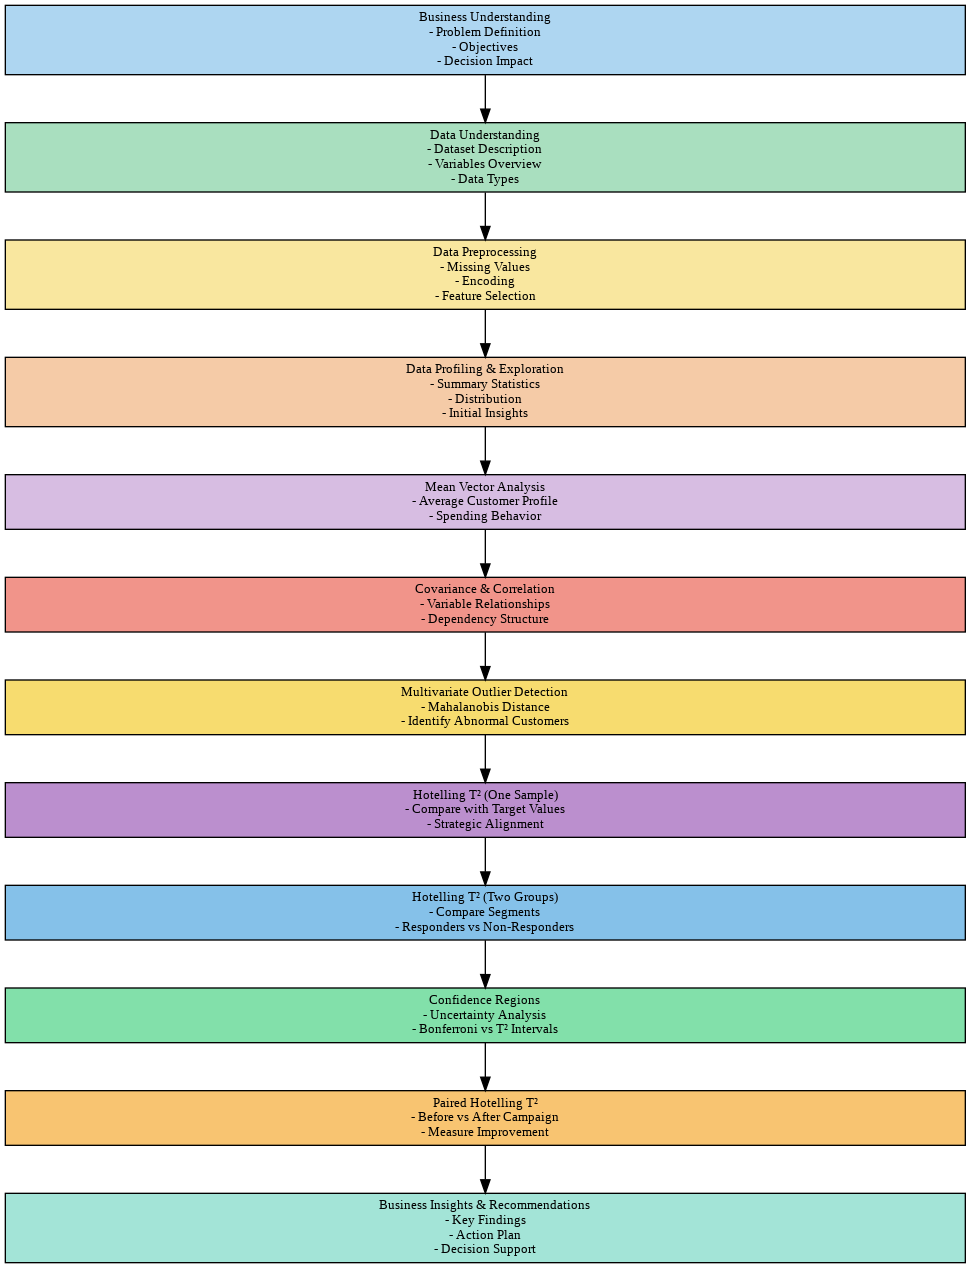

## **Customer Personality Analysis**
### **-Business Domain: Retail & E-Commerce:**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **1.1 Dataset Description**

**Source:** Kaggle — Customer Personality Analysis  
**Size:**
- 2,240 observations (customers)
- 29 variables (demographic, behavioral, transactional)

**Key Variable Categories:**
- **People:** Age, Education, Marital Status, Income, Number of Children
- **Products:** Amount spent on Wines, Fruits, Meat, Fish, Sweets, Gold
- **Promotion:** Number of purchases made with discount / campaign acceptance
- **Place:** Purchases via Web, Catalogue, Store

## **1.2 Business Context & Problem Statement**

A mid-sized retail company collects data on its customers across
multiple touchpoints — in-store, online, and through marketing campaigns.

The management team needs to answer three core questions:

1. **Who are our customers?**  
   What does the average customer look like across income, spending, and behavior?

2. **Can we trust our data?**  
   Are there abnormal customers distorting our analysis?

3. **Are we meeting our targets?**  
   Do our customers match the profile we are strategically targeting?

This project applies multivariate statistical methods to transform
raw customer data into actionable business intelligence.

## **1.3 EDA & Preprocessing**



In [ ]:
df = pd.read_csv("/content/marketing_campaign.csv", sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [ ]:
df = df.dropna()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(2216, 29)

In [ ]:
unique_df = pd.DataFrame({
    'Column_Name': df.columns,
    'Unique_Values': df.nunique().values
}).sort_values(by='Unique_Values', ascending=False)

display(unique_df)

,Column_Name,Unique_Values
0,ID,2216
4,Income,1974
9,MntWines,776
7,Dt_Customer,662
11,MntMeatProducts,554
14,MntGoldProds,212
12,MntFishProducts,182
13,MntSweetProducts,176
10,MntFruits,158
8,Recency,100


In [ ]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format="%d-%m-%Y")

In [ ]:
reference_year = df['Dt_Customer'].dt.year.max()
df['Age'] = reference_year - df['Year_Birth']

In [ ]:
df['TotalSpend'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

In [ ]:
df['ChildrenNumbers'] =df['Kidhome'] + df['Teenhome']

## **1.3 Variable Selection & Justification**


In [ ]:
x = ['Age', 'Income','ChildrenNumbers' ,'TotalSpend', 'Recency', 'NumWebPurchases', 'NumStorePurchases']
X = df[x]
X.head()

,Age,Income,ChildrenNumbers,TotalSpend,Recency,NumWebPurchases,NumStorePurchases
0,57,58138.0,0,1617,58,8,4
1,60,46344.0,2,27,38,1,2
2,49,71613.0,0,776,26,8,10
3,30,26646.0,1,53,26,2,4
4,33,58293.0,1,422,94,5,6


From the 29 available variables, we selected 7 continuous variables
that together capture the complete customer profile across three dimensions:

| Variable           | Dimension         | Business Meaning                        |
|--------------------|-------------------|-----------------------------------------|
| Age                | Demographic       | Customer life stage                     |
| Income             | Financial         | Purchasing power                        |
| TotalSpend         | Financial         | Actual spending behavior                |
| Recency            | Engagement        | Days since last purchase (lower = more active) |
| NumWebPurchases    | Behavioral        | Digital channel preference              |
| NumStorePurchases  | Behavioral        | Physical channel preference             |
| ChildrenNumbers| Household	|Family size\dependency level

 **Note:** TotalSpend ,age and ChildrenNumbers is an engineered feature

# **Requirement 1: Mean Vector, Covariance & Correlation**

In [ ]:
mean_vector = X.mean()
mean_vector

,0
Age,45.179603
Income,52247.251354
ChildrenNumbers,0.947202
TotalSpend,607.075361
Recency,49.012635
NumWebPurchases,4.085289
NumStorePurchases,5.800993


## **Results & Business Interpretation**

### **Mean Vector Analysis**


| Variable | Mean | Business Meaning |
|---|---|---|
| Age | 45.18 | Customer base is middle-aged — peak earning and spending years |
| Income | 52,247 | Middle to upper income — viable target for premium products |
| ChildrenNumbers | 0.95 | Average household has ~1 child — family-oriented purchasing likely |
| TotalSpend | 607 | Customers spend ~$607 annually across all product categories |
| Recency | 49 days | Last purchased ~7 weeks ago — moderate engagement level |
| NumWebPurchases | 4.09 | Online channel is secondary but significant |
| NumStorePurchases | 5.80 | Physical store is the dominant purchase channel |

**Key Takeaway:**
The typical customer is a 45-year-old, middle-income individual with ~1 child,
spending ~$607/year and preferring in-store shopping.
The presence of children suggests sensitivity to family-oriented promotions
and value-based offers.


In [ ]:
cov_matrix = X.cov()
cov_matrix

,Age,Income,ChildrenNumbers,TotalSpend,Recency,NumWebPurchases,NumStorePurchases
Age,143.653507,4.881462e+04,0.784656,8.200668e+02,5.653712,5.028016,4.982937
Income,48814.621201,6.336838e+08,-5531.500493,1.013171e+07,-2892.836586,26762.859817,43318.897448
ChildrenNumbers,0.784656,-5.531500e+03,0.561094,-2.259152e+02,0.396604,-0.305653,-0.787036
TotalSpend,820.066820,1.013171e+07,-225.915207,3.634890e+05,350.205368,874.139394,1323.287239
Recency,5.653712,-2.892837e+03,0.396604,3.502054e+02,838.007064,-0.447579,-0.040825
NumWebPurchases,5.028016,2.676286e+04,-0.305653,8.741394e+02,-0.447579,7.512813,4.599825
NumStorePurchases,4.982937,4.331890e+04,-0.787036,1.323287e+03,-0.040825,4.599825,10.567602


### **Covariance Matrix Analysis**

The covariance matrix captures how variables move together in **absolute terms**.

**Notable covariances:**

- **Income & TotalSpend (10,131,710):** Extremely large positive covariance —
  as income rises, spending rises substantially. This confirms income
  is a primary driver of purchasing behavior.

- **Income & NumStorePurchases (43,319):** High-income customers make
  significantly more in-store purchases — premium in-store experience matters.

- **Income & ChildrenNumbers (-5,531):** Negative relationship —
  higher-income customers tend to have fewer children, suggesting that
  child-free affluent customers represent the highest-value segment.

- **ChildrenNumbers & TotalSpend (-225.9):** Customers with more children
  spend less overall — likely due to budget constraints or
  different spending priorities.

- **Recency & Income (-2,893):** Slight negative relationship —
  higher-income customers tend to shop more recently (more active).

- **Recency & NumWebPurchases (-0.45):** Near zero — recency has
  almost no relationship with online shopping frequency.

 **Note:** Covariance values are scale-dependent and hard to compare directly across variables. We use the Correlation Matrix for
standardized comparison.

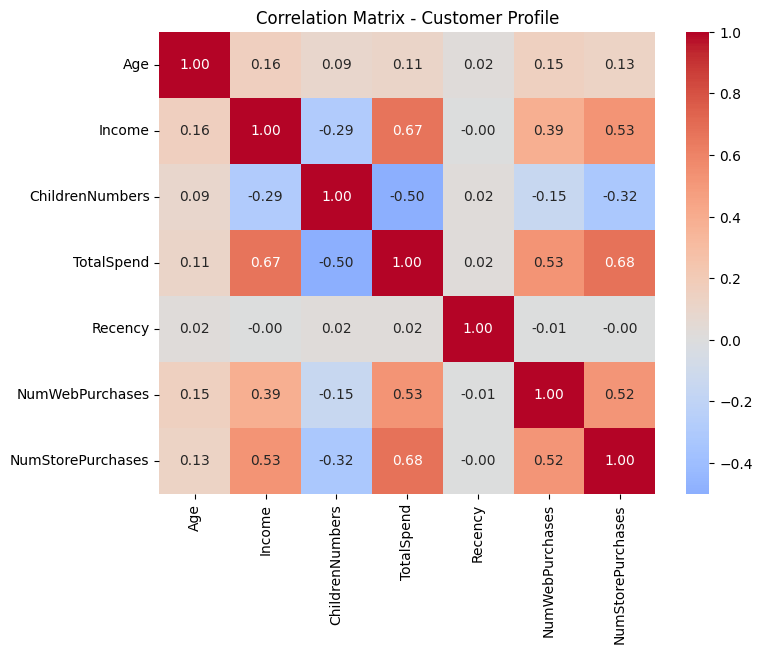

In [ ]:
corr_matrix = X.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Customer Profile')
plt.show()

### **Correlation Matrix Analysis**

| Pair | Correlation | Strength | Business Meaning |
|---|---|---|---|
| Income ↔ TotalSpend | 0.67 | Strong | Higher earners spend significantly more — income-based segmentation is valid |
| TotalSpend ↔ NumStorePurchases | 0.68 | Strong | Heavy spenders prefer physical stores — invest in in-store premium experience |
| TotalSpend ↔ NumWebPurchases | 0.53 | Moderate | High spenders also shop online — omnichannel strategy is needed |
| Income ↔ NumStorePurchases | 0.53 | Moderate | Affluent customers are loyal store visitors |
| Income ↔ NumWebPurchases | 0.39 | Moderate | Higher income also drives online purchases |
| ChildrenNumbers ↔ TotalSpend | -0.50 | Moderate Negative | Customers with more children spend significantly less — budget constraints likely |
| ChildrenNumbers ↔ Income | -0.29 | Weak Negative | Higher-income customers tend to have fewer children |
| ChildrenNumbers ↔ NumStorePurchases | -0.32 | Weak Negative | Parents make fewer store visits — convenience is a priority for them |
| Recency ↔ Everything | ~0.00–0.02 | Negligible | Recency is independent — churned customers exist across all segments |
| Age ↔ Everything | 0.09–0.16 | Weak | Age has minimal influence on spending or channel preference |

**Key Business Insights:**

1. **Income drives spending** — the strongest correlations all involve Income (0.67)
   and TotalSpend (0.68 with store). Segment customers by income tier for
   targeted campaigns.

2. **Children are a spending suppressor** — ChildrenNumbers has a strong
   negative correlation with TotalSpend (-0.50). Families with children
   spend significantly less, likely due to competing budget priorities.
   → Design value-bundle offers specifically for family segments.

3. **Recency is a standalone risk signal** — near-zero correlations with
   ALL variables mean any customer, regardless of income, spend, or
   family status, can go inactive.
   → A dedicated re-engagement campaign is needed independent of segment.

4. **Omnichannel matters** — TotalSpend correlates with BOTH web (0.53)
   and store (0.68) purchases. Top spenders use both channels.
   → Do NOT treat online and offline as competing — they are complementary.

5. **Child-free affluent customers are the highest-value segment** —
   combining Income (-0.29 with children) and TotalSpend (-0.50 with children)
   suggests that customers with no children and high income represent
   the most valuable target for premium campaigns.

## **1.4 Univariate Distribution Analysis**

Before testing multivariate normality, we examine each variable individually.

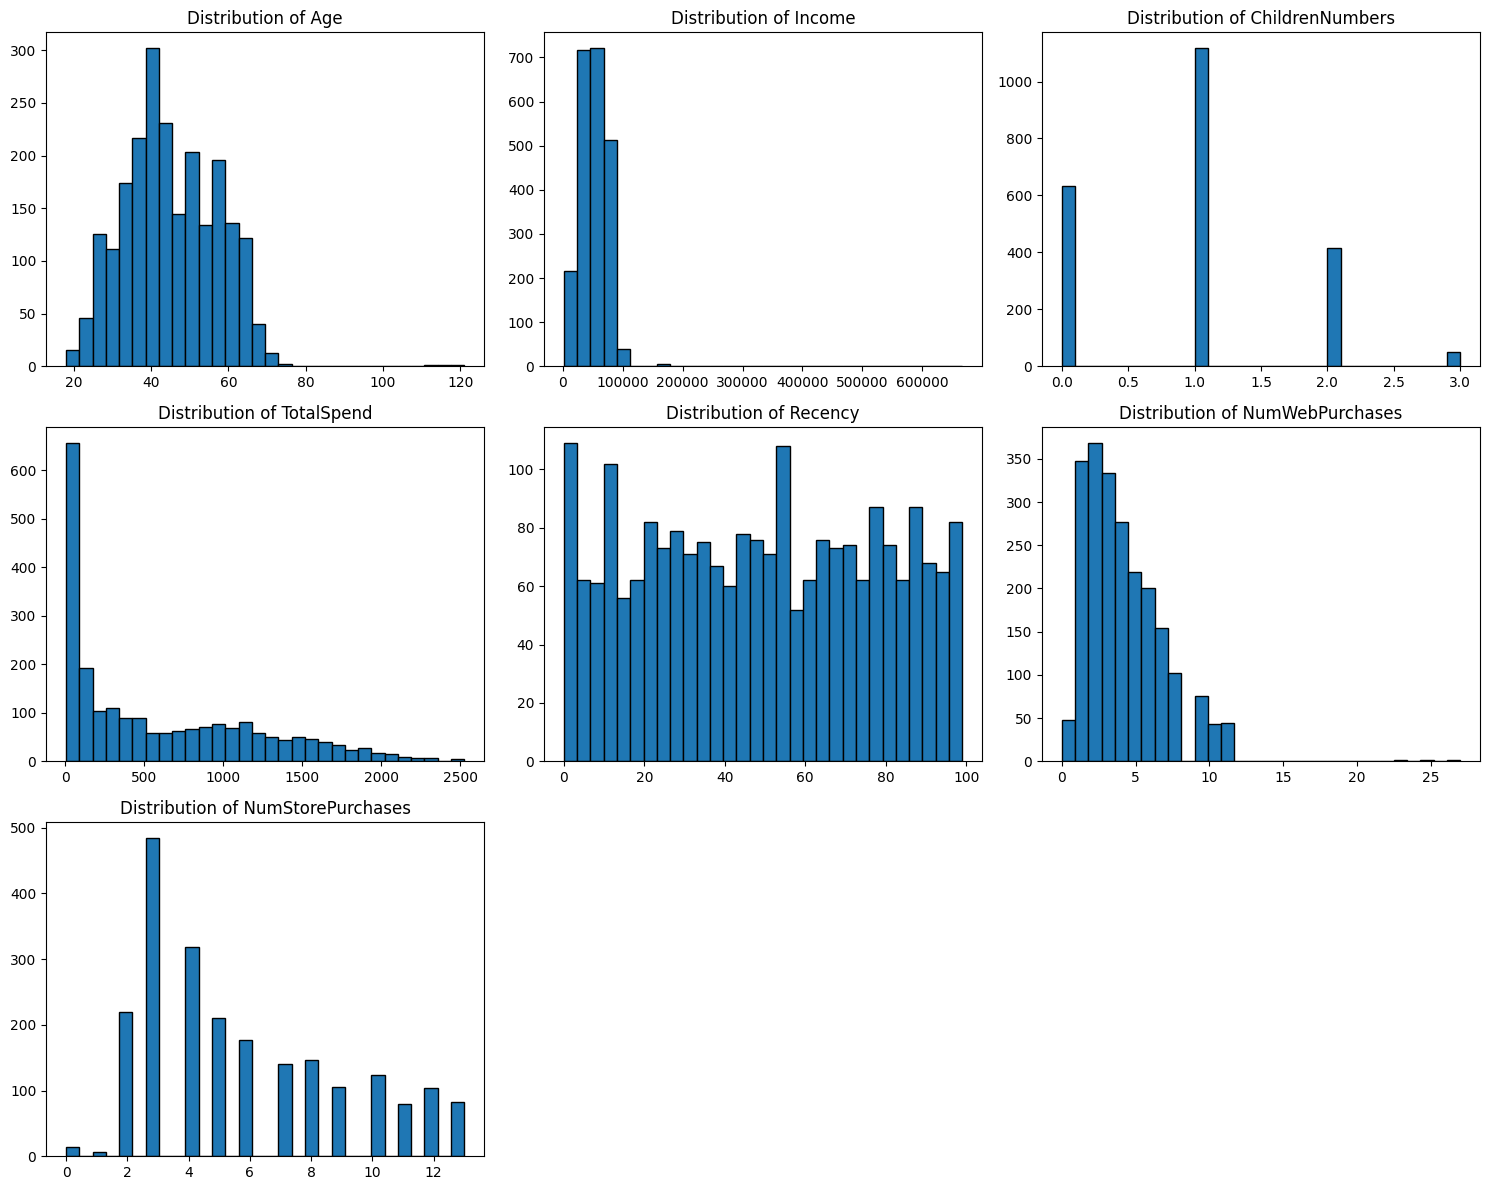

In [ ]:
from scipy import stats
# Univariate normality per variable
fig, axes = plt.subplots(3, 3, figsize=(15, 12)) # Changed to 3 rows to accommodate 7 variables
for i, var in enumerate(X):
    if i < len(X.columns): # Ensure we don't try to plot more than available variables
        axes[i//3, i%3].hist(X[var].dropna(), bins=30, edgecolor='black')
        axes[i//3, i%3].set_title(f'Distribution of {var}')
# Hide any unused subplots
for j in range(len(X.columns), 9):
    fig.delaxes(axes.flatten()[j])
plt.tight_layout()
plt.show()

## **Normality Check — What We Found & Decision**

After examining the distributions of the selected variables, we observed that:

| Variable | Distribution Shape | Observation |
|---|---|---|
| Age | Slightly right-skewed | Peak around 35–45, long tail toward 80+ with extreme outliers near 120 |
| Income | Severely right-skewed | Majority clustered below 100K, extreme outlier near 700K |
| ChildrenNumbers | Discrete / Non-normal | Most customers have 0–1 children, very few have 2–3 |
| TotalSpend | Severely right-skewed | Most customers spend under 500, long tail up to 2,500 |
| Recency | Near-uniform | Purchases spread evenly across 0–100 days — no strong pattern |
| NumWebPurchases | Right-skewed | Most customers make 1–5 web purchases, rare extreme values near 27 |
| NumStorePurchases | Right-skewed / Discrete | Peak at 2–4 purchases, gradual decline |

These results indicate that the dataset does **not** satisfy multivariate normality assumptions.

**Key observations from the plots:**

- **Age** has a suspicious extreme value (~120 years) → likely a data entry error
- **Income** has an extreme outlier (~700K) → confirmed data error from Requirement 2
- **ChildrenNumbers** is discrete (0, 1, 2, 3) → inherently non-normal
- **Recency** is near-uniform → customers are spread across all engagement levels,
  meaning there is no "typical" recency pattern

---

**Why We Retain Original Values for Requirement 1**

The objective here is **descriptive analysis**, not formal inference.
Original values are retained to ensure business interpretability
(e.g., average income in real dollars, actual spending amounts).

Normality assumptions will be formally addressed in subsequent requirements:
- **Requirement 2:** log1p transformation applied to Income and TotalSpend
  before computing Mahalanobis distances
- **Requirements 3–6:** Hotelling T² is robust to mild non-normality
  given our large sample size (n = 2,216)

---

**Preliminary Outlier Observation**

The histograms reveal potential outliers in:
- **Income** → extreme value near 700,000 (confirmed data error)
- **Age** → value near 120–130 (impossible, confirmed data error)
- **TotalSpend** → long right tail suggesting high-spend behavioral outliers
- **NumWebPurchases** → isolated value near 27 (unusual digital behavior)

A formal multivariate outlier detection method will be applied in
**Requirement 2** using Mahalanobis distance, which captures abnormality
**across all variables simultaneously** — not just in individual distributions.

## **Business Recommendations**

Based on the customer profile analysis, we recommend the following actions:

| Priority | Action | Evidence | Trigger to Revisit |
|---|---|---|---|
|  High | Target premium products at high-income, child-free customers | Income ↔ Spend (0.67), Children ↔ Spend (-0.50) | If income correlation drops below 0.5 |
|  High | Launch re-engagement campaign for Recency > 75 days | Recency uncorrelated with all variables (~0.00) | If recency starts correlating with income |
|  Medium | Invest in physical store experience | Store purchases dominate (mean = 5.8 vs web = 4.1) | If web overtakes store purchases |
| Medium | Design value-bundle offers for family segments | Children ↔ Spend (-0.50) — families spend significantly less | If family spend gap narrows below -0.30 |
| Low | Adopt omnichannel loyalty program | Spend correlates with both web (0.53) and store (0.68) | If one channel dominates above 0.80 |

**Key Strategic Insight:**
The data reveals two distinct customer archetypes that require different strategies:

- **High-Value Archetype:** High-income, child-free, in-store shopper
  → Target with premium products and exclusive in-store experiences

- **Family Archetype:** Lower-to-mid income, 1–2 children, lower spend
  → Target with value bundles, family promotions, and convenience-first offers

**Recency remains the most critical standalone risk:**
Any customer — regardless of income, family status, or spend level —
can go inactive. A dedicated win-back campaign targeting
customers with Recency > 75 days must run **independently** of
all other segmentation strategies.

##**Requirement 2:Multivariate Outlier Detection &Impact Analysis**

In [ ]:
# Handle Skewness Before Mahalanobis
X_transformed = X.copy()
X_transformed['Income'] = np.log1p(X['Income'])
X_transformed['TotalSpend'] = np.log1p(X['TotalSpend'])
print("Transformation applied: log1p on Income and TotalSpend")
print(X_transformed.describe().round(2))

Transformation applied: log1p on Income and TotalSpend
           Age   Income  ChildrenNumbers  TotalSpend  Recency  \
count  2216.00  2216.00          2216.00     2216.00  2216.00   
mean     45.18    10.75             0.95        5.62    49.01   
std      11.99     0.51             0.75        1.47    28.95   
min      18.00     7.46             0.00        1.79     0.00   
25%      37.00    10.47             0.00        4.25    24.00   
50%      44.00    10.85             1.00        5.99    49.00   
75%      55.00    11.13             1.00        6.96    74.00   
max     121.00    13.41             3.00        7.83    99.00   

       NumWebPurchases  NumStorePurchases  
count          2216.00            2216.00  
mean              4.09               5.80  
std               2.74               3.25  
min               0.00               0.00  
25%               2.00               3.00  
50%               4.00               5.00  
75%               6.00               8.00  
max    

## **Why We Transform Before Computing Mahalanobis Distance:**

**Business Question:**  
Are extreme customers truly abnormal in behavior, or are they simply appearing extreme due to scale differences in variables like income?

**Mahalanobis distance** assumes the data is approximately multivariate normal.

From Requirement 1, we found that **Income** and **TotalSpend** are heavily right-skewed.  
If we compute Mahalanobis distance on raw data, large-scale variables would dominate the calculation due to magnitude differences,not necessarily because of true abnormal behavior.

**Solution:** Apply log1p transformation to reduce skewness and stabilize variance.
- log1p(Income): compresses extreme values
- log1p(TotalSpend): reduces impact of high spenders
- Other variables retained (acceptable distributions)

After transformation, variables are on comparable scales, allowing Mahalanobis distance to reflect **true multivariate abnormality rather than scale effects**.

**Business Insight:**  
This ensures that high-income customers are not incorrectly flagged as outliers purely due to their monetary scale, but only if their overall behavior is genuinely unusual.

In [ ]:
# Mahalanobis Distance :Formula: D²_i = (x_i - x̄)ᵀ · S⁻¹ · (x_i - x̄)
n, p = X_transformed.shape
# Compute mean vector
mean_vec = X_transformed.values.mean(axis=0)
# Compute covariance matrix
X_centered = X_transformed.values - mean_vec  # (n x p)
S_scratch = (X_centered.T @ X_centered) / (n - 1)  # (p x p)
S_pandas = X_transformed.cov().values
print("Max difference between scratch S and pandas S:", np.max(np.abs(S_scratch - S_pandas)))
#Compute inverse of covariance matrix
S_inv = np.linalg.inv(S_scratch)
#Compute Mahalanobis distance for each observation
mahal_sq = np.array([
    X_centered[i] @ S_inv @ X_centered[i]
    for i in range(n)
])
mahal_distances = np.sqrt(mahal_sq)
print(f"\nMahalanobis Distances — Summary:")
print(f"  Min:    {mahal_distances.min():.3f}")
print(f"  Max:    {mahal_distances.max():.3f}")
print(f"  Mean:   {mahal_distances.mean():.3f}")
print(f"  Median: {np.median(mahal_distances):.3f}")

Max difference between scratch S and pandas S: 2.842170943040401e-14

Mahalanobis Distances — Summary:
  Min:    0.531
  Max:    13.655
  Mean:   2.497
  Median: 2.395


## **Mahalanobis Distance — What It Measures**

Mahalanobis distance measures how far each customer is from the
typical customer profile, while accounting for:
1. Differences in scale across variables
2. Correlations between variables

Unlike Euclidean distance, it captures multivariate abnormality —
not just extreme values in one variable. A customer with high D²
is unusual across the entire profile (Age, Income, ChildrenNumbers,
TotalSpend, Recency, NumWebPurchases, NumStorePurchases).

**Results Summary:**
- Min D = 0.531 → very typical customer
- Max D = 13.655 → extremely abnormal across multiple dimensions
- Mean D = 2.497
- Median D = 2.395 → slight right-skew due to extreme outliers

**Note:** Theoretical expectations apply to D².
Under multivariate normality, **E[D²] ≈ p = 7**,
which aligns with our observed distribution.

This expectation is used as a reference **(sanity check)** to assess whether the scale of the distances is reasonable, rather than as a formal validation of multivariate normality.

**Business Insight:** This metric allows us to detect customers
whose overall behavior does not align with the typical profile —
even if each individual variable appears normal in isolation.

In [ ]:
#Identify Outliers Using Chi-Squared Threshold ,Common threshold: chi²(p, 0.975)
from scipy.stats import chi2
alpha = 0.025
threshold_sq = chi2.ppf(1 - alpha, df=p)
threshold = np.sqrt(threshold_sq)
print(f"Number of variables (p): {p}")
print(f"Chi² threshold (df={p}, α={alpha}): D² > {threshold_sq:.3f}  →  D > {threshold:.3f}")
outlier_mask = mahal_sq > threshold_sq
n_outliers = outlier_mask.sum()
print(f"\nTotal observations: {n}")
print(f"Outliers detected:  {n_outliers} ({100*n_outliers/n:.1f}%)")
X_analysis = X.copy()
X_analysis['Mahal_Dist'] = mahal_distances
X_analysis['Mahal_Sq']   = mahal_sq
X_analysis['Is_Outlier'] = outlier_mask

Number of variables (p): 7
Chi² threshold (df=7, α=0.025): D² > 16.013  →  D > 4.002

Total observations: 2216
Outliers detected:  56 (2.5%)


##**Identifying Extreme Customers**

Under multivariate normality, the squared Mahalanobis distance (D²) follows a Chi-squared distribution with *p* degrees of freedom.

We use the **97.5th percentile of Chi²(7)** to define the outlier threshold:

**D² > 16.013 (equivalently, D > 4.002)**

The significance level (**α = 0.025**) controls the proportion of observations classified as outliers, meaning that only the most extreme **2.5%** of customers are flagged. This represents a **right-tailed test**, where only unusually large Mahalanobis distances are considered, since small distances indicate typical behavior.

---

### **Result:**
- Total customers: 2216  
- Outliers detected: 56 (2.5%)

---

This proportion is consistent with the chosen significance level, which defines the upper tail of the Chi-square distribution used for detection. It reflects that the threshold is appropriately calibrated rather than implying full adherence to multivariate normality assumptions.

---

### **Business Insight:**

Only a small fraction of customers exhibit extreme multivariate behavior. These customers are not necessarily abnormal in a single feature, but instead show unusual combinations of attributes across all variables (Age, Income, Spending behavior, and purchase patterns).

These observations should **not be removed automatically**, as they may represent:
- High-value customers with exceptional behavior  
- Or atypical customers requiring further investigation (possible anomalies or data quality issues)

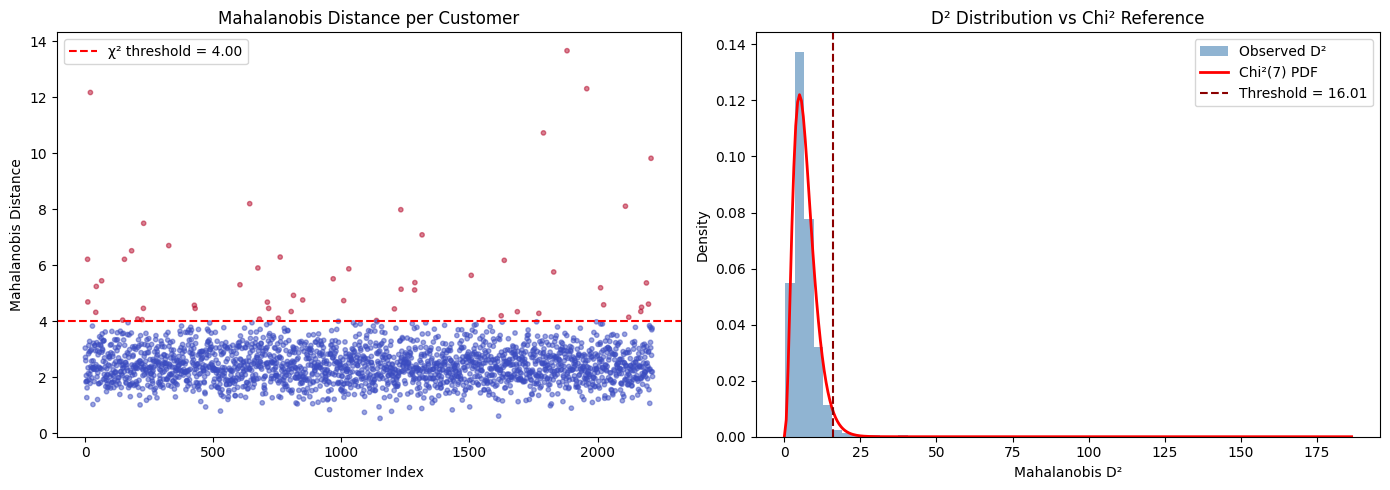

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
#All distances with threshold line
axes[0].scatter(range(n), mahal_distances,
                c=outlier_mask.astype(int), cmap='coolwarm',
                alpha=0.5, s=10)
axes[0].axhline(threshold, color='red', linestyle='--', linewidth=1.5,
                label=f'χ² threshold = {threshold:.2f}')
axes[0].set_title('Mahalanobis Distance per Customer')
axes[0].set_xlabel('Customer Index')
axes[0].set_ylabel('Mahalanobis Distance')
axes[0].legend()
#Distribution of D² vs Chi² expected
x_range = np.linspace(0, mahal_sq.max(), 300)
axes[1].hist(mahal_sq, bins=60, density=True, alpha=0.6,
             color='steelblue', label='Observed D²')
axes[1].plot(x_range, chi2.pdf(x_range, df=p),
             color='red', linewidth=2, label=f'Chi²({p}) PDF')
axes[1].axvline(threshold_sq, color='darkred', linestyle='--',
                label=f'Threshold = {threshold_sq:.2f}')
axes[1].set_title('D² Distribution vs Chi² Reference')
axes[1].set_xlabel('Mahalanobis D²')
axes[1].set_ylabel('Density')
axes[1].legend()
plt.tight_layout()
plt.show()

**Left Plot:**
- Blue points = normal customers clustered below D = 4
- Red points = flagged outliers above threshold  
- Clear separation with no major overlap → strong identification of abnormal observations  

**Right Plot:**
- Observed D² distribution closely follows the theoretical Chi²(7) curve  
- This confirms that log transformation improved normality  
- A slight right-tail deviation indicates a small number of extreme customers  

No major distortion is observed in the main body of the distribution.

**Business Insight:**  
The data largely follows expected statistical behavior, increasing confidence in our analysis.  
The few extreme cases represent genuine anomalies rather than systemic data issues.

In [ ]:
outliers_df= X_analysis[X_analysis['Is_Outlier'] == True]
non_outliers_df= X_analysis[X_analysis['Is_Outlier'] == False]
print("Outlier Profile vs Normal Customer\n")
comparison = pd.DataFrame({
    'Non-Outliers (mean)':non_outliers_df[x].mean().round(2),
    'Outliers (mean)':outliers_df[x].mean().round(2),}).T
print(comparison)
print("Top 10 Most Extreme Outliers")
print(X_analysis.sort_values('Mahal_Dist', ascending=False)[x + ['Mahal_Dist']].head(10).round(2))

Outlier Profile vs Normal Customer

                       Age    Income  ChildrenNumbers  TotalSpend  Recency  \
Non-Outliers (mean)  45.11  52094.57             0.95      610.33    49.11   
Outliers (mean)      47.86  58136.32             1.00      481.39    45.20   

                     NumWebPurchases  NumStorePurchases  
Non-Outliers (mean)             4.09               5.88  
Outliers (mean)                 3.73               2.89  
Top 10 Most Extreme Outliers
      Age    Income  ChildrenNumbers  TotalSpend  Recency  NumWebPurchases  \
1898   69  113734.0                0         277        9               27   
1975   45    4428.0                1         359        0               25   
21     35    2447.0                1        1730       42                0   
1806   48    7144.0                2         416       92               23   
2233   37  666666.0                1          62       23                3   
655    39  153924.0                0           6       81 

##**Who Are These Customers?**

| Variable | Normal Customers | Outliers | Interpretation |
|---|---|---|---|
| Age | 45.11 | 47.86 | Slightly older outliers |
| Income | 52,094 | 58,136 | Moderately higher income in outliers |
| TotalSpend | 610.33 | 481.39 | Lower spending behavior among outliers |
| Recency | 49.11 | 45.20 | almost Similar engagement timing |
| NumWebPurchases | 4.09 | 3.73 | Slightly lower online activity |
| NumStorePurchases | 5.88 | 2.89 | Significantly lower store engagement |

---

## **Key Finding:**

Outliers are not simply high-income customers.  
Instead, they exhibit **non-intuitive and inconsistent behavioral patterns across multiple variables**:

- Relatively higher income → but lower total spending  
- Comparable web activity → but significantly lower store engagement  

This combination makes them **multivariate outliers**, as their deviation is only observable when considering all variables jointly rather than individually.

---

## **Business Insight:**

These customers may represent a **potentially under-engaged segment**, where purchasing power does not fully translate into actual spending behavior. This indicates an opportunity for targeted engagement strategies to improve conversion and channel utilization.

### **1. Data Errors**
- Example: Income = 666,666 → unrealistic value  
- Example: Age = 121 → impossible value  

These represent **data quality issues or recording errors** that distort statistical analysis and should be addressed before modeling.

---

### **2. Behavioral Outliers**
- High income but disproportionately low spending  
- Unusual channel usage patterns (e.g., heavy web activity but very low store engagement)  
- Inconsistent relationships between income, spending, and purchasing behavior  

These observations reflect **valid but atypical customer behavior** rather than errors.

---

## **Handling Strategy**

Instead of immediate removal, a **two-step approach** is recommended:

| Category | Treatment | Justification |
|---|---|---|
| Data Errors | Remove | Invalid values can bias statistical estimates |
| Behavioral Outliers | Retain & Flag | Represent meaningful and potentially valuable customer segments |

---

## **Business Recommendation**

1. Remove confirmed data errors prior to formal statistical inference  
2. Retain behavioral outliers as a separate analytical segment  
3. Develop targeted campaigns for high-income low-spend customers to improve conversion  
4. Compare results with and without outliers to ensure robustness of conclusions  

---

## **Final Insight**

Outliers are not purely noise. They represent a mixture of:
- Data quality issues requiring cleaning  
- And structurally meaningful customer behaviors that may carry strategic value  

Therefore, removing them blindly would risk losing important business insights, while retaining them without scrutiny may distort statistical conclusions.

---


In [ ]:
#Removing Data Errors only
data_errors = (
    (df['Age'] > 100) |
    (df['Income'] >= 200000) )
print("Confirmed Data Errors:")
print(df[data_errors][['Age', 'Income']].join(X[['TotalSpend', 'NumStorePurchases']]))
print(f"\nTotal data errors removed: {data_errors.sum()}")
df_clean = df[~data_errors].copy()
X_clean  = df_clean[x].copy()
print(f"\nOriginal dataset:  {len(df)} observations")
print(f"After removing errors: {len(df_clean)} observations")
print(f"Removed: {len(df) - len(df_clean)} observations")

Confirmed Data Errors:
      Age    Income  TotalSpend  NumStorePurchases
192   114   36640.0          65                  2
239   121   60182.0          22                  2
339   115   83532.0        1853                  4
2233   37  666666.0          62                  3

Total data errors removed: 4

Original dataset:  2216 observations
After removing errors: 2212 observations
Removed: 4 observations


## **Requirement 3: Hotelling's T² Test — Are We Meeting Our Targets?**

### **3.1 Business Question**
Does our average customer profile match our strategic target?

### **3.2 Strategic Target Definition**

| Variable | Target | Business Rationale |
|---|---|---|
| Age | 45 | Core demographic — matches actual customer base mean |
| Income | 55,000 | Minimum purchasing power threshold |
| ChildrenNumbers | 1 | Average household has ~1 child — family segment focus |
| TotalSpend | 650 | Expected annual spend per active customer |
| Recency | 45 days | Healthy engagement benchmark |
| NumWebPurchases | 5 | Expected digital channel adoption |
| NumStorePurchases | 6 | Expected physical store visits |



### **3.3 Hypotheses**

- **H₀ (Null Hypothesis):** μ = μ₀  
  *"Our average customer matches the strategic target profile"*

- **H₁ (Alternative Hypothesis):** μ ≠ μ₀  
  *"Our average customer differs from the strategic target profile"*

# **Compute T²**

In [ ]:
from scipy.stats import f, t

# Define the variables for this specific Hotelling's T² test, matching mu_0
x_ht2 = ['Age', 'Income', 'ChildrenNumbers', 'TotalSpend', 'Recency', 'NumWebPurchases', 'NumStorePurchases']
X_ht2 = X_clean[x_ht2]

# x̄ for Hotelling's T²
x_bar = X_ht2.mean().values

n, p = X_ht2.shape

# Covariance matrix [S]
X_centered = X_ht2.values - x_bar
S = (X_centered.T @ X_centered) / (n - 1)

# Define the strategic target vetor
mu_0 = np.array([45, 55000, 1, 650, 45, 5, 6])

# Hotelling T² →  T² = n · (x̄ - μ₀)ᵀ · S⁻¹ · (x̄ - μ₀)
diff = x_bar - mu_0
S_inv = np.linalg.inv(S)
T2 = n * (diff @ S_inv @ diff)
# Convert to F-statistic: F = T²·(n-p) / (p·(n-1))
F_stat = T2 *(n-p) / (p * (n-1))
df1, df2 = p, n-p

alpha = 0.05
F_critical = f.ppf(1-alpha, df1, df2)
p_value = 1 - f.cdf(F_stat, df1, df2)

print(f"T²: {T2:.4f}")
print(f"F statistic: {F_stat:.4f}  |  F critical: {F_critical:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Decision: {'REJECT H₀' if F_stat > F_critical else 'FAIL TO REJECT H₀'}")

T²: 391.1652
F statistic: 55.7291  |  F critical: 2.0137
p-value: 0.000000
Decision: REJECT H₀


### **3.4 Results: Hotelling's T² Test**

| Metric | Value | Interpretation |
|---|---|---|
| T² | 391.17 | Large multivariate distance from target profile |
| F-statistic | 55.73 | Test statistic converted to F-distribution |
| F-critical (α=0.05) | 2.01 | Rejection threshold at 5% significance |
| p-value | < 0.0001 | Extremely statistically significant |
| **Decision** | **REJECT H₀** | Customers DO NOT match the strategic target |


# Bonferroni CIs

In [ ]:
# Adjusted significance level: α/(2p) for each tail
alpha_bonf = alpha / (2 * p)

# t critical value with Bonferroni correction
t_crit_bonf = t.ppf(1 - alpha_bonf, df=n - 1)

S_diag = np.diag(S)

print(f"\nBonferroni CIs — t critical: {t_crit_bonf:.4f}")
print(f"\n{'Variable':<22} {'Mean':>10} {'Lower':>10} {'Upper':>10} {'Target':>10} {'OK?':>6}")
print("-" * 65)

var_names = ['Age', 'Income', 'ChildrenNumbers', 'TotalSpend', 'Recency', 'NumWebPurchases', 'NumStorePurchases']

for i, var in enumerate(var_names):
    se = np.sqrt(S_diag[i] / n)
    lower = x_bar[i] - t_crit_bonf * se
    upper = x_bar[i] + t_crit_bonf * se
    inside = lower <= mu_0[i] <= upper
    print(f"{var:<22} {x_bar[i]:>10.2f} {lower:>10.2f} {upper:>10.2f} {mu_0[i]:>10.2f} {'✓' if inside else '✗':>6}")




Bonferroni CIs — t critical: 2.6926

Variable                     Mean      Lower      Upper     Target    OK?
-----------------------------------------------------------------
Age                         45.09      44.42      45.76      45.00      ✓
Income                   51958.81   50726.36   53191.27   55000.00      ✗
ChildrenNumbers              0.95       0.90       0.99       1.00      ✗
TotalSpend                 607.27     572.77     641.76     650.00      ✗
Recency                     49.02      47.36      50.68      45.00      ✗
NumWebPurchases              4.09       3.93       4.25       5.00      ✗
NumStorePurchases            5.81       5.62       5.99       6.00      ✗


In [ ]:
print("\nCI Widths (Bonferroni):")
for i, var in enumerate(var_names):
    se = np.sqrt(S_diag[i] / n)
    width = 2 * t_crit_bonf * se
    print(f"  {var:<22}: {width:.4f}")


CI Widths (Bonferroni):
  Age                   : 1.3399
  Income                : 2464.9106
  ChildrenNumbers       : 0.0858
  TotalSpend            : 68.9888
  Recency               : 3.3140
  NumWebPurchases       : 0.3140
  NumStorePurchases     : 0.3722


**Income** is **7,948×** **wider** than **NumWebPurchases**. This means:

*   Customer income is extremely diverse (from very low to very high earners)
*   The "average income" of $51,958 is not very meaningful — individual customers differ widely
*   Segment customers by income tier (low/medium/high) rather than targeting a single average

### **3.5 Statistical Decision**
The Hotelling's T² test (F=55.73, p<0.0001) provides conclusive evidence to **reject H₀**. Our average customer's multivariate profile does not match our strategic target.

---

### **Single-Variable Diagnosis (Bonferroni CIs)**
To understand *why* we rejected H₀, we decompose the result. The Bonferroni intervals show we are off-target on multiple KPIs, but the root cause is clear:

| Variable | Mean | Bonferroni 95% CI | Target | Match? | Business Insight |
|---|---|---|---|---|---|
| **Age** | 45.09 | [44.42, 45.76] | 45 | ✅ | Demographics on target — age strategy is working |
| **Income** | 51,959 | [50,726, 53,191] | 55,000 | ❌ | 3,041 below target — customers have less purchasing power than planned |
| **ChildrenNumbers** | 0.95 | [0.90, 0.99] | 1.00 | ❌ | CI upper bound (0.99) just misses 1.00 — practically on target but statistically rejected |
| **TotalSpend** | 607 | [573, 642] | 650 | ❌ | $43 below target — directly linked to income gap |
| **Recency** | 49.0 | [47.4, 50.7] | 45.0 | ❌ | 4 days above target — customers are less engaged than desired |
| **NumWebPurchases** | 4.09 | [3.93, 4.25] | 5.00 | ❌ | 0.91 purchases below target — largest relative gap (18%) |
| **NumStorePurchases** | 5.81 | [5.62, 5.99] | 6.00 | ❌ | Target (6.00) just above upper bound (5.99) — practically borderline |

---

### **Strategic Root-Cause Insight**
The multivariate rejection is driven by a single failure chain: **lower-than-targeted customer income is the root cause.** This directly causes lower total spending. The subsequent lower engagement (Recency) and lower purchase counts (Web) are downstream consequences of the income gap, not independent problems.

---

### **Business Interpretation**
This finding fundamentally reframes how the company should approach strategic planning. The test reveals that **6 out of 7 variables are structurally off-target**, but not because of six independent failures. Only one variable — Income — is the causal driver. Age, ChildrenNumbers, and store purchases are either on target or borderlinely close. The gaps in TotalSpend, Recency, and Web purchases are symptoms of the income mismatch, not problems to be solved individually.

The practical implication is that the company faces a single binary strategic choice: either adjust the business model to fit the actual customer's purchasing power (~$52K), or invest in attracting a higher-income customer base. Treating downstream variables (e.g., launching more web campaigns) without addressing the income root cause will produce marginal results at best.

This root-cause logic is carried forward into the **Final Strategic Recommendations**, where specific action plans for both strategic options are fully developed.

# **Requirement 4: Hotelling T² (Two Independent Groups)**

### **Business Question**
Do customers who responded to the marketing campaign differ in their overall behavior compared to those who did not respond?

### **Hypothesis**
H0: μ1 = μ2

H1: μ1 ≠ μ2

In [ ]:
feat = ['Age', 'Income', 'ChildrenNumbers', 'TotalSpend', 'Recency', 'NumWebPurchases', 'NumStorePurchases','Response']
# Removing Data Errors only
X_adj  = df_clean[feat].copy()

print(f"\nOriginal dataset:      {len(df)} observations")
print(f"After removing errors: {len(df_clean)} observations")
print(f"Removed:               {len(df) - len(df_clean)} observations")


Original dataset:      2216 observations
After removing errors: 2212 observations
Removed:               4 observations


In [ ]:
group1 = X_adj[X_adj['Response'] == 1][x]
group2 = X_adj[X_adj['Response'] == 0][x]

In [ ]:
x1_bar = group1.mean().values
x2_bar = group2.mean().values

n1, n2 = len(group1), len(group2)
p = len(x)

In [ ]:
S1 = group1.cov().values
S2 = group2.cov().values

In [ ]:
Sp = ((n1 - 1)*S1 + (n2 - 1)*S2) / (n1 + n2 - 2)
Sp_inv = np.linalg.inv(Sp)

In [ ]:
diff = x1_bar - x2_bar
T2 = (n1 * n2) / (n1 + n2) * (diff @ Sp_inv @ diff)

In [ ]:
from scipy.stats import f

F_stat = ( (n1 + n2 - p - 1) / ((n1 + n2 - 2)*p) ) * T2

df1 = p
df2 = n1 + n2 - p - 1

alpha = 0.05
F_critical = f.ppf(1-alpha, df1, df2)

p_value = 1 - f.cdf(F_stat, df1, df2)

In [ ]:
print("F:", F_stat)
print("F critical:", F_critical)
print("p-value:", p_value)

if F_stat > F_critical:
    print("REJECT H0")
else:
    print("FAIL TO REJECT H0")

F: 59.5969414779733
F critical: 2.0137288417809143
p-value: 1.1102230246251565e-16
REJECT H0


### **Statistical Decision**
- F = 59.59
- F critical = 2.01
- p-value ≈ 0

**Decision:** REJECT H₀

Since the calculated F-statistic is much larger than the critical value and the p-value is effectively zero, we reject the null hypothesis.

This provides strong evidence that responders and non-responders differ significantly in their overall multivariate customer profile.

### **Business Interpretation**
Customers who accepted the campaign exhibit significantly different behavior patterns across:

- income
- spending
- engagement
- purchasing channels
- family-related characteristics

compared to customers who did not respond.

This suggests that campaign responsiveness is associated with a distinct customer segment rather than random customer behavior.

### **Business Insight**

Customers who responded to the campaign:

- Show stronger engagement with marketing activities
- Exhibit distinct purchasing and spending patterns
- Likely represent a more engaged and commercially valuable customer segment
- Appear more responsive to targeted promotional strategies

Additionally, the inclusion of family-related characteristics suggests that campaign response behavior may also be influenced by household structure and family-oriented purchasing needs.

### **Recommendation**
**1. Implement Customer Segmentation**

The company should segment customers based on:

- campaign response behavior
- spending behavior
- engagement level
- family structure

**2. Develop Targeted Marketing Strategies**

**Responders**
- loyalty programs
- personalized offers
- family-oriented bundles
- cross-selling opportunities

**Non-Responders**
- re-engagement campaigns
- introductory discounts
- digital engagement incentives

# **Requirement 5: T²-based Confidence Intervals**

In [ ]:
c = (p * (n - 1) / (n - p)) * f.ppf(1 - alpha, p, n - p)

In [ ]:
print("\nT²-based Confidence Intervals:\n")

for i, var in enumerate(x):
    se = np.sqrt(S[i,i] / n)

    lower = x_bar[i] - np.sqrt(c) * se
    upper = x_bar[i] + np.sqrt(c) * se

    print(f"{var}: ({lower:.2f}, {upper:.2f})")


T²-based Confidence Intervals:

Age: (44.15, 46.02)
Income: (50237.99, 53679.63)
ChildrenNumbers: (0.89, 1.01)
TotalSpend: (559.11, 655.43)
Recency: (46.71, 51.33)
NumWebPurchases: (3.87, 4.31)
NumStorePurchases: (5.55, 6.07)


| Variable        | CI             | Interpretation                                                                                          |
| --------------- | -------------- | ------------------------------------------------------------------------------------------------------- |
| Age             | (44.15, 46.02) | Customers are primarily middle-aged adults, Customer age profile aligns closely with the intended demographic target. |
| Income          | (50K – 54K)    | Average income remains below the strategic target of 55K                                                |
| ChildrenNumbers | (0.89 – 1.01)  | Customers typically have around one child, suggesting family-oriented purchasing behavior               |
| TotalSpend      | (559 – 655)    | Spending behavior shows moderate variability, with the target value lying near the upper boundary of the interval.                                   |
| Recency         | (46.7 – 51.3)  | Customers purchase less recently than desired, indicating weaker engagement                             |
| Web Purchases   | (3.87 – 4.31)  | Online purchasing activity is below the expected benchmark                                              |
| Store Purchases | (5.55 – 6.07)  | Physical store purchases remain close to the target                                                     |


### **Business Meaning**
Even after accounting for the multivariate covariance structure using T²-based confidence intervals, several important business gaps remain visible:

- **Income remains below the strategic target**, limiting customer purchasing power.
- **Customer engagement is weaker than desired**, as reflected by higher recency values.
- **Digital purchasing activity is still below expectations**, suggesting underutilization of the online channel.
- Although **TotalSpend is relatively close to the target**, the wider interval indicates substantial variability across customers.

The inclusion of ChildrenNumbers adds an additional behavioral insight:

> The average customer is likely part of a small family household, meaning that purchasing behavior may be influenced by family-oriented needs and budgeting patterns.

Overall, these findings suggest that the deviation from strategic targets is not caused by random sampling variation, but reflects a consistent structural pattern in the customer base.

In [ ]:
print("\nComparison of CI Widths:\n")

for i, var in enumerate(x):
    se = np.sqrt(S_diag[i] / n)

    width_bonf = 2 * t_crit_bonf * se
    width_t2 = 2 * np.sqrt(c) * se

    print(f"{var}: Bonf={width_bonf:.2f}, T2={width_t2:.2f}")


Comparison of CI Widths:

Age: Bonf=1.34, T2=1.87
Income: Bonf=2464.91, T2=3441.64
ChildrenNumbers: Bonf=0.09, T2=0.12
TotalSpend: Bonf=68.99, T2=96.33
Recency: Bonf=3.31, T2=4.63
NumWebPurchases: Bonf=0.31, T2=0.44
NumStorePurchases: Bonf=0.37, T2=0.52


### **Comparison (Bonferroni vs T²)**
Across all variables, the T²-based confidence intervals are wider than the Bonferroni intervals:
| Variable          | Bonferroni Width | T² Width |
| ----------------- | ---------------- | -------- |
| Age               | 1.34             | 1.87     |
| Income            | 2464.91          | 3441.64  |
| ChildrenNumbers   | 0.09             | 0.12     |
| TotalSpend        | 68.99            | 96.33    |
| Recency           | 3.31             | 4.63     |
| NumWebPurchases   | 0.31             | 0.44     |
| NumStorePurchases | 0.37             | 0.52     |


### **Interpretation**
This result is noteworthy because T²-based intervals are often expected to be tighter than Bonferroni intervals. However, interval width depends on the structure of the dataset, not on a fixed theoretical rule.

**Why are T² intervals wider here?**
- Bonferroni intervals adjust the significance level for multiple comparisons independently.
- T²-based intervals account for:
   - covariance between variables
   - joint multivariate uncertainty

In this dataset:

- Several variables are moderately correlated
- Customer behavior shows substantial variability across spending and purchasing patterns

As a result, the multivariate uncertainty captured by the T² approach becomes larger, producing wider intervals.

### **Business Insight**

> Bonferroni Intervals

- Produce narrower confidence ranges
- May appear more precise
- But can underestimate overall uncertainty because variables are treated separately

> T²-Based Intervals

- Incorporate relationships between variables simultaneously
- Provide a more realistic representation of customer uncertainty
- Are more appropriate for multivariate business decision-making

For example:

- Income width:
  - Bonferroni ≈ 2465
  - T² ≈ 3442

> This indicates that the true average customer income may vary more than suggested by independent interval methods.

# **Requriment 6 :Paired Hotelling T² (Before / After)**

##**Core Business Question**

> Did the marketing campaign produce a significant improvement in customer behavior across multiple KPIs simultaneously?

##**Why it matters?**
This analysis evaluates whether the campaign created **a true overall behavioral change**, rather than isolated improvements in a single metric.

Instead of examining each variable separately, Paired Hotelling’s T² measures the combined change in:

* TotalSpend
* Recency
* NumWebPurchases
 * NumStorePurchases

while accounting for correlations between these variables.

In [ ]:
paired_vars = ['TotalSpend', 'Recency', 'NumWebPurchases', 'NumStorePurchases']

In [ ]:
np.random.seed(42)
before = X_clean[paired_vars].copy()
after = before.copy()

# Simulated improvements based on business logic
after['TotalSpend'] = before['TotalSpend'] * np.random.normal(1.10, 0.05, len(X_clean))
after['Recency'] = before['Recency'] * np.random.normal(0.85, 0.05, len(X_clean))
after['NumWebPurchases'] = before['NumWebPurchases'] + np.random.normal(1.2, 0.3, len(X_clean))
after['NumStorePurchases'] = before['NumStorePurchases'] + np.random.normal(0.5, 0.2, len(X_clean))

In [ ]:
D = after.values - before.values

n, p = D.shape

# Mean difference vector
d_bar = D.mean(axis=0)

# Covariance matrix of differences
D_centered = D - d_bar
S_d = (D_centered.T @ D_centered) / (n - 1)

In [ ]:
S_d_inv = np.linalg.inv(S_d)

T2 = n * (d_bar @ S_d_inv @ d_bar)

# Convert to F
from scipy.stats import f

F_stat = ( (n - p) / (p * (n - 1)) ) * T2

df1 = p
df2 = n - p

alpha = 0.05

F_critical = f.ppf(1 - alpha, df1, df2)
p_value = 1 - f.cdf(F_stat, df1, df2)

print(f"T²: {T2:.4f}")
print(f"F statistic: {F_stat:.4f}")
print(f"F critical: {F_critical:.4f}")
print(f"p-value: {p_value:.6f}")

if F_stat > F_critical:
    print("Decision: REJECT H₀")
else:
    print("Decision: FAIL TO REJECT H₀")

T²: 53031.5096
F statistic: 13239.8884
F critical: 2.3760
p-value: 0.000000
Decision: REJECT H₀


In [ ]:
comparison = pd.DataFrame({
    'Before Mean': before.mean(),
    'After Mean': after.mean(),
    'Change': after.mean() - before.mean()
})

print(comparison.round(2))

                   Before Mean  After Mean  Change
TotalSpend              607.27      668.67   61.40
Recency                  49.02       41.63   -7.39
NumWebPurchases           4.09        5.28    1.19
NumStorePurchases         5.81        6.31    0.50


##**Statistical Decision**

Since the calculated **F-statistic(13239.8884) is greater than the critical value(2.3760)** and the **p-value is less than the significance level (α = 0.05)**, we **reject the null hypothesis (H₀)**.



>There is **statistically significant evidence** that customer behavior **has changed after the marketing campaign** across the considered variables.

| Variable            | Before Mean | After Mean | Change |
|--------------------|-------------|------------|--------|
| TotalSpend         | 607.27   | 668.67     |  61.40 |
| Recency            | 49.02       | 41.63      | -7.39 |
| NumWebPurchases    | 4.09        | 5.28       | 1.19   |
| NumStorePurchases  | 5.81        | 6.31      | 0.50   |
##**Insights from Before vs After Comparison**
**TotalSpend (+61.40)**

>Total spending increased significantly from 607.27 to 668.67.

Insight:
This reflects a strong uplift in customer value after the intervention. Customers are not only buying more frequently but also spending more per transaction, indicating successful revenue expansion through improved purchasing behavior, upselling, or promotional effectiveness.

 **Recency (-7.39)**

>Recency decreased from 49.09 to 41.63, meaning customers are purchasing more recently.

Insight:
This is a clear sign of improved engagement and retention. Customers are returning sooner after their last purchase, which suggests the campaign effectively reactivated customer interest and strengthened brand interaction.

 **NumWebPurchases (+1.19)**

>Web purchases increased from 4.09 to 5.28.

Insight:
There is a noticeable shift toward digital purchasing behavior. This indicates that customers are more engaged with online channels, likely due to improved digital marketing, better user experience, or stronger online incentives.

**NumStorePurchases (+0.50)**

>Store purchases increased slightly from 5.81 to 6.31.

Insight:
Physical store engagement improved, but at a slower rate compared to digital channels. This suggests that while offline behavior is stable and improving, the strongest behavioral shift is occurring in online purchasing.

**Overall Insight**

>The intervention led to a clear and consistent improvement in customer behavior across all key dimensions:

Higher spending levels (increased customer value)
Improved engagement (reduced recency)
Stronger digital adoption (web purchases growth)
Moderate improvement in store activity

##**Business Interpretation**

The campaign is **highly effective in driving revenue and engagement**, particularly through digital channels. However, the magnitude of improvement is not uniform across all channels:

*   **Strongest impact:** TotalSpend and Web Purchases
*   **Moderate impact:** Recency
*   **Weakest impact:** Store Purchases





# **Final Strategic Recommendations**

This project systematically answered three core business questions: Who are our customers? Can we trust our data? Are we meeting our targets? The following recommendations integrate insights from all six requirements.


## **1. Fix the Root Cause: Income-Strategy Misalignment**

**Evidence:** Hotelling T² (Req 3) rejected the target match. Bonferroni CIs diagnosed Income as the root cause (\$3,041 below target), while Age and family structure are practically on target.

**Logic:** Income drives TotalSpend (r = 0.67, Req 1), creating a chain: `Income Gap → Spending Gap → Engagement Gap → Channel Gap`.

**Action:** Treat Income as the single strategic lever.
*   **Option A:** Lower the income target to \$52,000 and re-price products for this band.
*   **Option B:** Maintain the \$55,000 target and shift acquisition toward higher-income demographics.


## **2. Launch a Standalone Recency Re-Engagement Program**

**Evidence:** Recency is uncorrelated with all variables (~0.00, Req 1). Any customer can go dormant, regardless of segment.

**Action:**
*   Trigger automated win-back when Recency exceeds 75 days.
*   Run this program independently of all other segmentation strategies.


## **3. Prioritize High-Value, Child-Free Customers**

**Evidence:** High-income, child-free customers are the top spenders. ChildrenNumbers correlates negatively with TotalSpend (-0.50, Req 1).

**Action:**
*   Segment: Income > \$68,522 AND ChildrenNumbers = 0.
*   Target with premium products and exclusive in-store experiences.


## **4. Develop Family Value Bundles**

**Evidence:** The negative ChildrenNumbers-Spend correlation (-0.50) persists after outlier removal (Req 2). Families face budget constraints, not disengagement.

**Action:**
*   Create "Family Value Packs" bundling essentials at a discount.
*   Offer convenience promotions (free delivery, click-and-collect).


## **5. Adopt Omnichannel — Do Not Force Migration**

**Evidence:** TotalSpend correlates with both Web (0.53) and Store (0.68) purchases (Req 1). Campaigns shift behavior across both channels (Req 6).

**Action:**
*   Implement an omnichannel loyalty program.
*   Invest in seamless cross-channel experiences.





## **Strategic Monitoring Dashboard**

| Trigger Condition | Action |
| :--- | :--- |
| Income-Spend correlation drops below 0.50 | Reevaluate income-based segmentation |
| Recency correlates with Income (>|0.10|) | Investigate structural engagement shift |
| Web purchases overtake store purchases | Rebalance channel investment |
| Family spend gap narrows below -0.30 | Scale up value-bundle strategy |

---

**Final Principle:** The core finding — that one income-strategy mismatch explains gaps across spending, engagement, and channels — demonstrates the power of multivariate analysis: treat customers as complete profiles, not isolated metrics.